<a href="https://colab.research.google.com/github/nithinrb/NVIDIA/blob/main/DAY_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install diffusers transformers accelerate torch pillow

In [18]:

from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import torch

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Stable Diffusion Image-to-Image Model
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

pipe = pipe.to(device)

# Load Input Cat Image
init_image = Image.open("/content/img.jpeg").convert("RGB")
init_image = init_image.resize((512, 512))

# Prompt
prompt = """
A cute fluffy white cat sitting in a magical garden,
highly detailed, realistic, cinematic lighting,
4k quality
"""

# Generate New Image
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.6,      # 0-1 (higher = more changes)
    guidance_scale=7.5
)

generated_image = result.images[0]

# Save Output
generated_image.save("generated_cat.png")

print("Image generated successfully!")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated successfully!


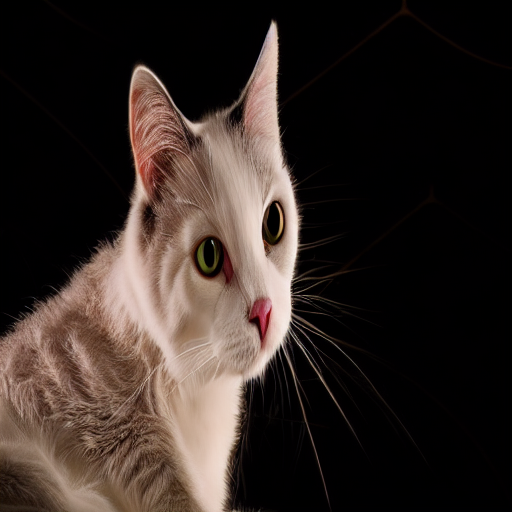

In [19]:
from IPython.display import Image
Image("generated_cat.png")

In [11]:
pip install tensorflow matplotlib numpy

Training Images Shape: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 [D loss: 0.8473, Acc: 42.58%] [G loss: 0.7637]
Epoch 100 [D loss: 3.7268, Acc: 12.80%] [G loss: 0.0250]
Epoch 200 [D loss: 4.3663, Acc: 12.71%] [G loss: 0.0127]
Epoch 300 [D loss: 4.7262, Acc: 12.64%] [G loss: 0.0085]
Epoch 400 [D loss: 4.9799, Acc: 12.64%] [G loss: 0.0064]
Epoch 500 [D loss: 5.1740, Acc: 12.64%] [G loss: 0.0051]
Epoch 600 [D loss: 5.3297, Acc: 12.65%] [G loss: 0.0043]
Epoch 700 [D loss: 5.4606, Acc: 12.68%] [G loss: 0.0037]
Epoch 800 [D loss: 5.5743, Acc: 12.73%] [G loss: 0.0032]
Epoch 900 [D loss: 5.6725, Acc: 12.75%] [G loss: 0.0028]
Epoch 1000 [D loss: 5.7613, Acc: 12.75%] [G loss: 0.0026]
Epoch 1100 [D loss: 5.8416, Acc: 12.75%] [G loss: 0.0023]
Epoch 1200 [D loss: 5.9152, Acc: 12.72%] [G loss: 0.0021]
Epoch 1300 [D loss: 5.9826, Acc: 12.71%] [G loss: 0.0020]
Epoch 1400 [D loss: 6.0443, Acc: 12.71%] [G loss: 0.0018]
Epoch 1500 [D loss: 6.1023, Acc: 12.71%] [G loss: 0.0017]
Epoch 1600 [D loss: 6.1562, Acc: 12.70%] [G loss: 0.0016]
Epoch 1700 [D loss: 6.2073

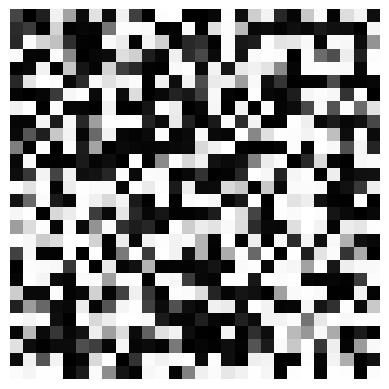

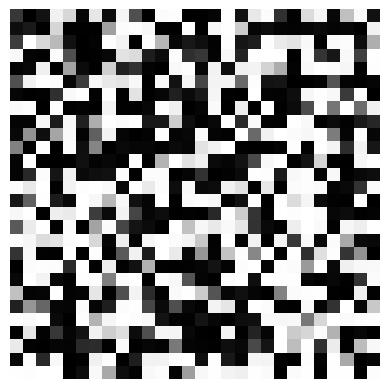

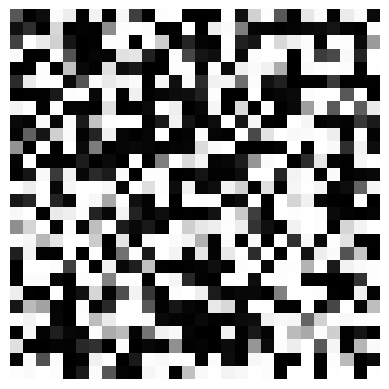

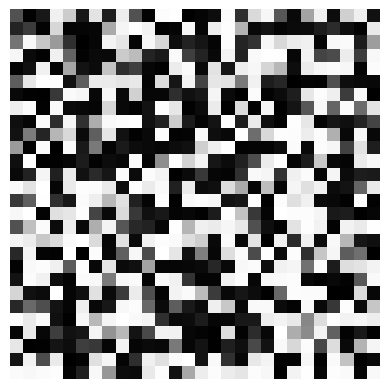

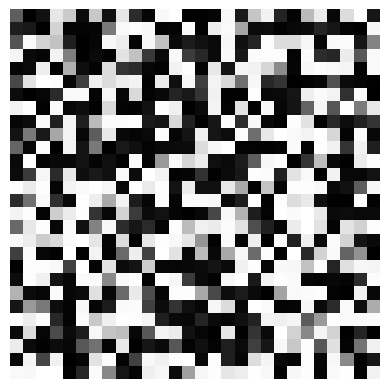

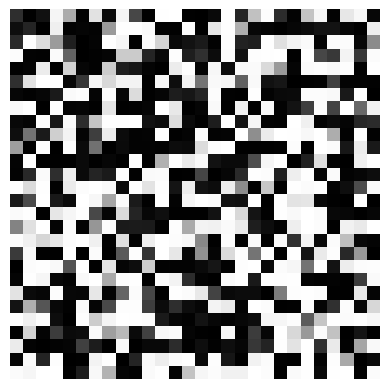

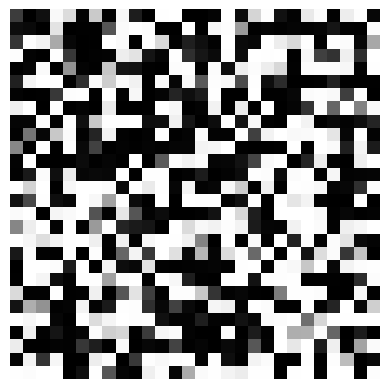

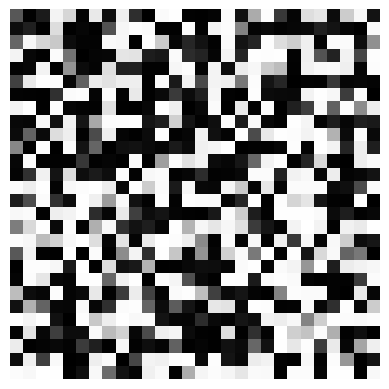

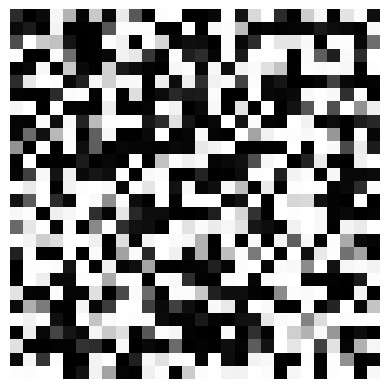

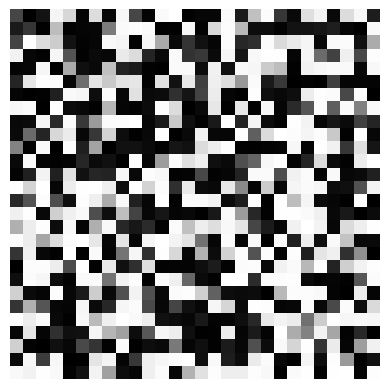

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Reshape,
    LeakyReLU,
    Input
)
from tensorflow.keras.optimizers import Adam

# ==========================
# Load and Prepare MNIST
# ==========================

(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

img_shape = (28, 28, 1)
latent_dim = 100

print("Training Images Shape:", X_train.shape)

# ==========================
# Generator
# ==========================

def build_generator():

    model = Sequential([
        Input(shape=(latent_dim,)),

        Dense(256),
        LeakyReLU(negative_slope=0.2),

        Dense(512),
        LeakyReLU(negative_slope=0.2),

        Dense(1024),
        LeakyReLU(negative_slope=0.2),

        Dense(784, activation="tanh"),

        Reshape(img_shape)
    ])

    return model

# ==========================
# Discriminator
# ==========================

def build_discriminator():

    model = Sequential([
        Input(shape=img_shape),

        Flatten(),

        Dense(512),
        LeakyReLU(negative_slope=0.2),

        Dense(256),
        LeakyReLU(negative_slope=0.2),

        Dense(1, activation="sigmoid")
    ])

    return model

# ==========================
# Build Models
# ==========================

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    metrics=["accuracy"]
)

# ==========================
# GAN Model
# ==========================

discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5)
)

# ==========================
# Save Generated Images
# ==========================

def save_images(epoch):

    rows, cols = 5, 5

    noise = np.random.normal(
        0, 1, (rows * cols, latent_dim)
    )

    generated_images = generator.predict(
        noise,
        verbose=0
    )

    # Rescale to [0,1]
    generated_images = 0.5 * generated_images + 0.5

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(8, 8)
    )

    count = 0

    for i in range(rows):
        for j in range(cols):

            axes[i, j].imshow(
                generated_images[count, :, :, 0],
                cmap="gray"
            )

            axes[i, j].axis("off")

            count += 1

    plt.tight_layout()

    plt.savefig(
        f"generated_epoch_{epoch}.png"
    )

    plt.close()

# ==========================
# Training Function
# ==========================

def train(
    epochs=10000,
    batch_size=128,
    save_interval=1000
):

    half_batch = batch_size // 2

    for epoch in range(epochs):

        # ------------------
        # Train Discriminator
        # ------------------

        idx = np.random.randint(
            0,
            X_train.shape[0],
            half_batch
        )

        real_images = X_train[idx]

        noise = np.random.normal(
            0,
            1,
            (half_batch, latent_dim)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        d_loss_real = discriminator.train_on_batch(
            real_images,
            np.ones((half_batch, 1))
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            np.zeros((half_batch, 1))
        )

        d_loss = 0.5 * np.add(
            d_loss_real,
            d_loss_fake
        )

        # ------------------
        # Train Generator
        # ------------------

        noise = np.random.normal(
            0,
            1,
            (batch_size, latent_dim)
        )

        valid_labels = np.ones(
            (batch_size, 1)
        )

        g_loss = gan.train_on_batch(
            noise,
            valid_labels
        )

        if epoch % 100 == 0:

            dloss = float(d_loss[0])
            dacc = float(d_loss[1])

            gloss = (
                float(g_loss[0])
                if isinstance(g_loss, (list, tuple))
                else float(g_loss)
            )

            print(
                f"Epoch {epoch} "
                f"[D loss: {dloss:.4f}, "
                f"Acc: {100*dacc:.2f}%] "
                f"[G loss: {gloss:.4f}]"
            )

        if epoch % save_interval == 0:
            save_images(epoch)

# ==========================
# Start Training
# ==========================

train(
    epochs=10000,
    batch_size=128,
    save_interval=1000
)

# ==========================
# Generate New Digits
# ==========================

noise = np.random.normal(
    0,
    1,
    (10, latent_dim)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

generated_images = (
    generated_images + 1
) / 2.0

for i in range(10):

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")
    plt.show()


In [20]:
import nbformat
import os

for file in os.listdir("/content"):
    if file.endswith(".ipynb"):
        try:
            nb = nbformat.read(file, as_version=4)

            if "widgets" in nb.metadata:
                del nb.metadata["widgets"]

            nbformat.write(nb, file)
            print(f"Fixed: {file}")

        except Exception as e:
            print(f"Error in {file}: {e}")